In [2]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
accounts = pd.read_csv(r"C:\csv\accounts.csv")
subscriptions = pd.read_csv(r"C:\csv\subscriptions.csv")
feature_usage = pd.read_csv(r"C:\csv\feature_usage.csv")
support_tickets = pd.read_csv(r"C:\csv\support_tickets.csv")
churn_events = pd.read_csv(r"C:\csv\churn_events.csv")

print("CSV files loaded successfully")

CSV files loaded successfully


In [4]:
accounts.columns = accounts.columns.str.strip().str.lower()
subscriptions.columns = subscriptions.columns.str.strip().str.lower()
feature_usage.columns = feature_usage.columns.str.strip().str.lower()
support_tickets.columns = support_tickets.columns.str.strip().str.lower()
churn_events.columns = churn_events.columns.str.strip().str.lower()

In [5]:
accounts.fillna("Unknown", inplace=True)
subscriptions.fillna(0, inplace=True)
feature_usage.fillna(0, inplace=True)
support_tickets.fillna(0, inplace=True)
churn_events.fillna("Unknown", inplace=True)

In [6]:
accounts["churn_flag"] = pd.to_numeric(
    accounts["churn_flag"],
    errors="coerce"
).fillna(0).astype(int)

In [7]:
feature_summary = feature_usage.groupby(
    "subscription_id"
).agg({
    "usage_count": "sum",
    "usage_duration_secs": "sum",
    "error_count": "sum"
}).reset_index()

feature_summary.rename(columns={
    "usage_count": "total_usage",
    "usage_duration_secs": "total_duration",
    "error_count": "total_errors"
}, inplace=True)

In [8]:
support_summary = support_tickets.groupby(
    "account_id"
).agg({
    "ticket_id": "count",
    "satisfaction_score": "mean",
    "escalation_flag": "sum"
}).reset_index()

support_summary.rename(columns={
    "ticket_id": "total_tickets",
    "satisfaction_score": "avg_satisfaction",
    "escalation_flag": "total_escalations"
}, inplace=True)

In [9]:
df = accounts.merge(
    subscriptions,
    left_on="customer_id",
    right_on="account_id",
    how="left"
)

df = df.merge(
    feature_summary,
    on="subscription_id",
    how="left"
)

df = df.merge(
    support_summary,
    left_on="customer_id",
    right_on="account_id",
    how="left"
)

df.fillna(0, inplace=True)

print(df.head())
print(df.shape)

  customer_id company_name industry country signup_date account_status  \
0    A-2e4581    Company_0   EdTech      US  16-10-2024        partner   
1    A-2e4581    Company_0   EdTech      US  16-10-2024        partner   
2    A-2e4581    Company_0   EdTech      US  16-10-2024        partner   
3    A-2e4581    Company_0   EdTech      US  16-10-2024        partner   
4    A-2e4581    Company_0   EdTech      US  16-10-2024        partner   

  plan_type  seats_x  is_trial_x  churn_flag_x  ... churn_flag_y  \
0     Basic        9       False             0  ...        False   
1     Basic        9       False             0  ...        False   
2     Basic        9       False             0  ...        False   
3     Basic        9       False             0  ...        False   
4     Basic        9       False             0  ...        False   

  billing_frequency auto_renew_flag total_usage total_duration  total_errors  \
0           monthly            True        42.0        12313.0    

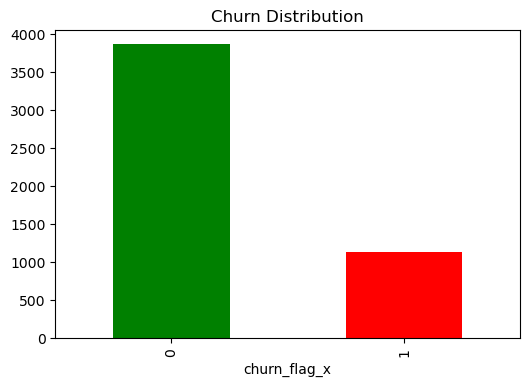

In [10]:
plt.figure(figsize=(6,4))

df["churn_flag_x"].value_counts().plot(
    kind="bar",
    color=["green", "red"]
)

plt.title("Churn Distribution")
plt.show()

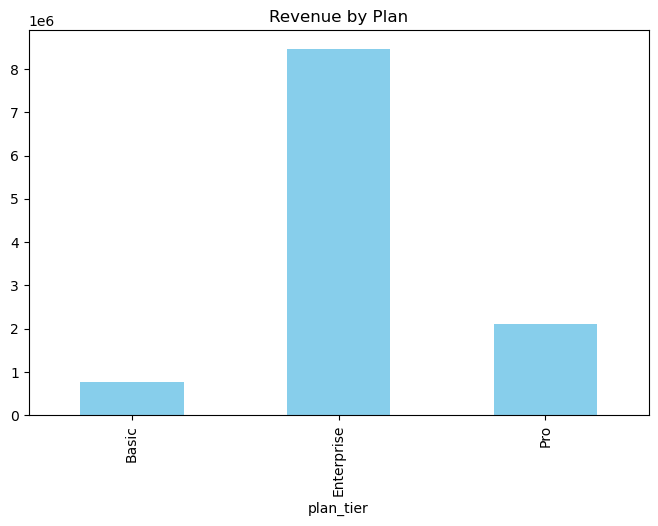

In [11]:
plt.figure(figsize=(8,5))

df.groupby("plan_tier")["mrr_amount"].sum().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Revenue by Plan")
plt.show()

In [12]:
target = "churn_flag_x"

drop_cols = [
    "customer_id",
    "company_name",
    "subscription_id",
    "account_id_x",
    "account_id_y",
    target
]

X = df.drop(
    columns=[c for c in drop_cols if c in df.columns]
)

y = df[target]

In [13]:
for col in X.select_dtypes(include="object").columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

X = X.apply(pd.to_numeric, errors="coerce")

X.fillna(0, inplace=True)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, log_pred))

print(classification_report(y_test, log_pred))

Accuracy:
0.769
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       769
           1       0.00      0.00      0.00       231

    accuracy                           0.77      1000
   macro avg       0.38      0.50      0.43      1000
weighted avg       0.59      0.77      0.67      1000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: Un

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy:
0.991
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       769
           1       1.00      0.96      0.98       231

    accuracy                           0.99      1000
   macro avg       0.99      0.98      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

             Feature  Importance
2        signup_date    0.164435
5            seats_x    0.121166
23  avg_satisfaction    0.114405
22     total_tickets    0.099495
0           industry    0.060024
3     account_status    0.059816
10           seats_y    0.055592
1            country    0.046002
4          plan_type    0.035939
20    total_duration    0.035004


In [19]:
df.to_csv(
    r"C:\Users\mekar\Desktop\saaspulse_ml_cleaned_dataset_v2.csv",
    index=False
)

importance.to_csv(
    r"C:\Users\mekar\Desktop\feature_importance_v2.csv",
    index=False
)

print("Project Completed Successfully")

Project Completed Successfully
